# Resident Evil - EDA & Social Network Analysis

1st notebook of the project -> https://www.kaggle.com/code/tommasofacchin/01-resident-evil-data-scraping-and-generation

2nd notebook of the project -> https://www.kaggle.com/code/tommasofacchin/02-resident-evil-dataset-demo

---

After creating the dataset and a small demo, we'll finish this project by studying how the main cast is organized as a social network.

- First we'll explore how the characters appeared in the games, and visualize the interaction between the characters.

- Then we'll explore basic Social Network Analysis and visualize a simple co-occurences graph.

- To finish, we detect communities to identify clusters of characters and analyze this clusters. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
import itertools

from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from itertools import combinations
from collections import Counter
import community as community_louvain

In [2]:
games = pd.read_csv("/kaggle/input/datasets/tommasofacchin/resident-evil/games.csv")
characters = pd.read_csv("/kaggle/input/datasets/tommasofacchin/resident-evil/characters.csv")
gameAppearance = pd.read_csv("/kaggle/input/datasets/tommasofacchin/resident-evil/gameAppearance.csv")
interactions = pd.read_csv("/kaggle/input/datasets/tommasofacchin/resident-evil/interactions.csv")
scenes = pd.read_csv("/kaggle/input/datasets/tommasofacchin/resident-evil/scenes.csv")

In [3]:
gameAppearance[gameAppearance["game_id"] == "re3"]

,game_id,character_id,role,game_title,character_name
28,re3,16,hero,Resident Evil 3: Nemesis,Jill Valentine
29,re3,18,support,Resident Evil 3: Nemesis,Brad Vickers
30,re3,30,support,Resident Evil 3: Nemesis,Marvin Branagh
31,re3,33,hero,Resident Evil 3: Nemesis,Carlos Oliveira
32,re3,34,villain,Resident Evil 3: Nemesis,Nemesis
33,re3,35,villain,Resident Evil 3: Nemesis,Nikolai Zinoviev
34,re3,36,support,Resident Evil 3: Nemesis,Mikhail Victor
35,re3,37,support,Resident Evil 3: Nemesis,Dario Rosso


In [4]:
border_subtle = "#2d333b"
accent       = "#3ecf8e"
accent_dark = "#1f7f54"
villain = "#e5534b"
background = "#0d1117"

inter_path = "/kaggle/input/datasets/tommasofacchin/inter-font/Inter_18pt-Regular.ttf"  
fm.fontManager.addfont(inter_path)

def set_sns_style():
    bg_page      = "#0d1117"
    bg_card      = "#161b22"
    text_primary = "#e6edf3"
    text_muted   = "#8b949e"

    sns.set_theme(style="whitegrid")
    sns.set_style({
        "axes.facecolor": bg_card,
        "figure.facecolor": bg_page,
        "axes.edgecolor": border_subtle,
        "axes.spines.right": False,
        "axes.spines.top": False,
        "grid.color": border_subtle,
        "grid.linestyle": "-",
        "grid.linewidth": 0.5,
    })
    sns.set_palette([accent, accent_dark])

    plt.rcParams.update({
        "figure.facecolor": bg_page,
        "axes.facecolor": bg_card,
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "text.color": text_primary,
        "axes.labelcolor": text_primary,
        "xtick.color": text_muted,
        "ytick.color": text_muted,
        "font.family": "Inter 18pt",#"sans-serif",
        "font.sans-serif": [
            "Inter",
            "system-ui",
            "-apple-system",
            "BlinkMacSystemFont",
            "Segoe UI",
            "DejaVu Sans",
        ],
    })

set_sns_style()

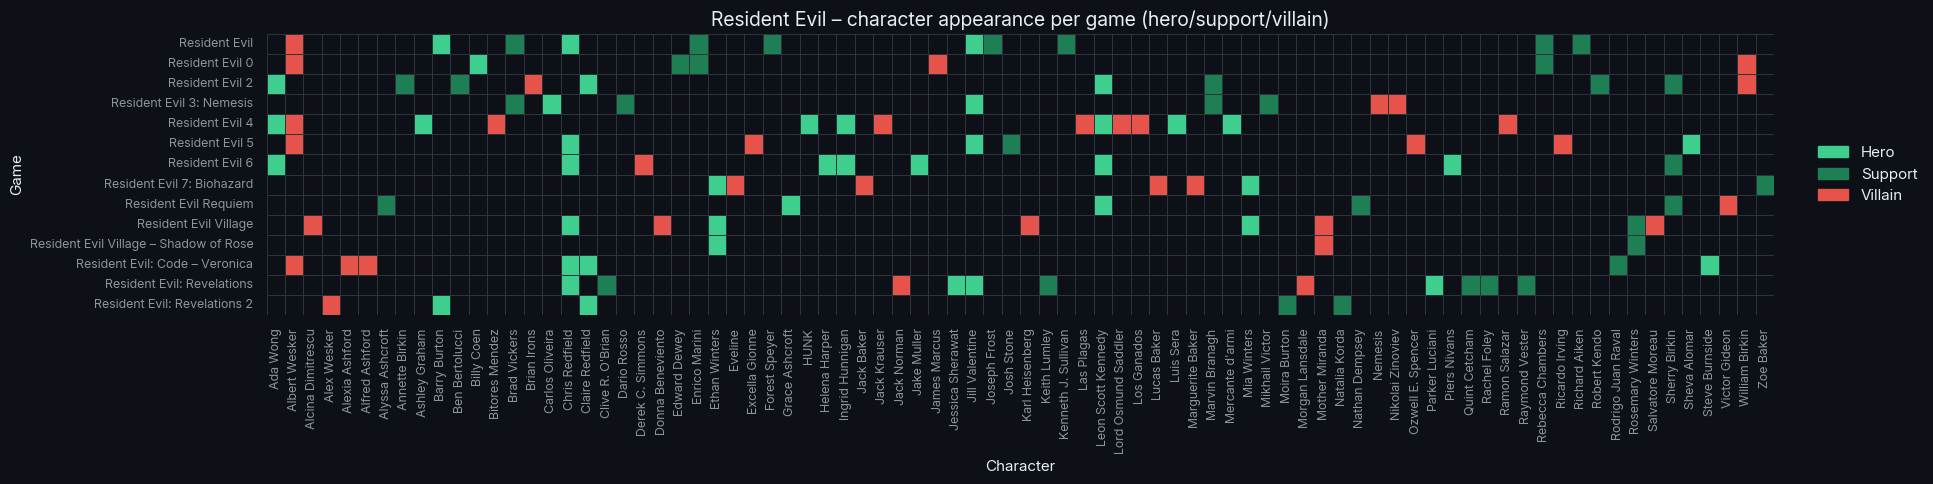

In [5]:
# Mapping id -> label
games_small = games[['id', 'title']].rename(columns={'id': 'game_id'})
chars_small = characters[['id', 'name']].rename(columns={'id': 'character_id'})

# Character presence in game (0/1)
pairs = (
    gameAppearance[['game_id', 'character_id']]
    .drop_duplicates()
)

pairs = (
    pairs
    .merge(games_small, on='game_id', how='left')
    .merge(chars_small, on='character_id', how='left')
)

pairs['presence'] = 1

heatmap_df = pairs.pivot_table(
    index='title',      # rows: games
    columns='name',     # cols: characters
    values='presence',
    fill_value=0
)

# Characters roles
chars_with_role = characters[['name', 'role']].drop_duplicates()
roles = chars_with_role.set_index('name').reindex(heatmap_df.columns)['role']

# Matrix values: 0 = no appearance, 1 = hero, 2 = support, 3 = villain
values = heatmap_df.values 
val_matrix = np.zeros_like(values, dtype=int)

role_mask_hero    = (roles == 'hero').values
role_mask_support = (roles == 'support').values
role_mask_villain = (roles == 'villain').values

val_matrix[(values == 1) & (role_mask_hero[np.newaxis, :])] = 1
val_matrix[(values == 1) & (role_mask_support[np.newaxis, :])] = 2
val_matrix[(values == 1) & (role_mask_villain[np.newaxis, :])] = 3

# Colormap 
bg      = background
hero_c  = accent       
supp_c  = accent_dark   
vill_c  = villain     

cmap_roles = ListedColormap([bg, hero_c, supp_c, vill_c])

plt.figure(figsize=(18, 5))
ax = sns.heatmap(
    val_matrix,
    cmap=cmap_roles,
    cbar=False,
    linewidths=.5,
    linecolor=border_subtle,
    xticklabels=heatmap_df.columns,
    yticklabels=heatmap_df.index
)
plt.title("Resident Evil – character appearance per game (hero/support/villain)")
plt.xlabel("Character")
plt.ylabel("Game")
plt.tight_layout()

# Legend
hero_patch    = mpatches.Patch(color=hero_c,  label="Hero")
support_patch = mpatches.Patch(color=supp_c,  label="Support")
villain_patch = mpatches.Patch(color=vill_c,  label="Villain")

plt.legend(
    handles=[hero_patch, support_patch, villain_patch],
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),  
    frameon=False
)

plt.savefig("appearance_heatmap.png")
plt.show()

In this image we can see a matrix where each row is a game, and each column is a character, the color indicate weather the character is a hero, support, or villain.

Most of the squares are clearly empty and only a few characters appear in more than 2 games.

The roles of the characters stays consistent throughout the games.

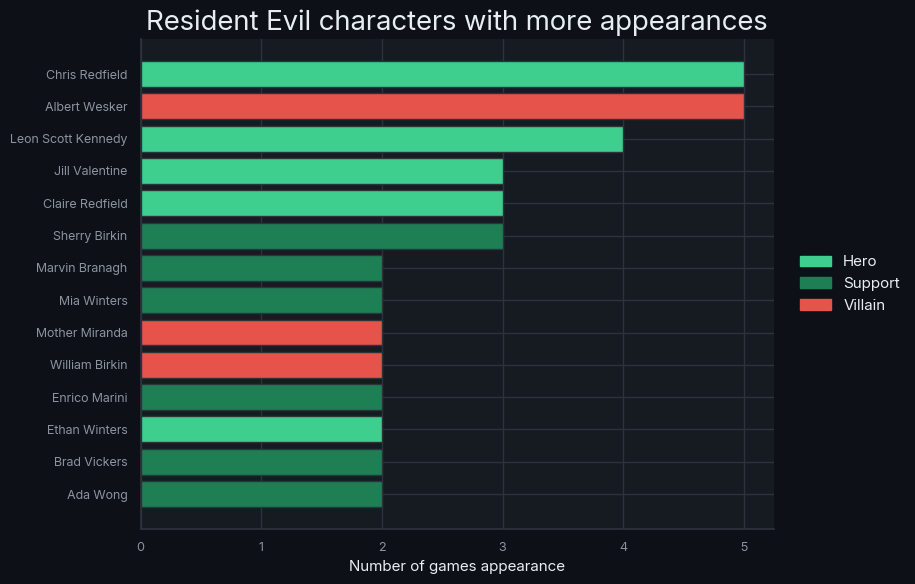

In [6]:
char_games = (
    gameAppearance[["character_name", "game_id", "role"]]
    .drop_duplicates()
    .groupby(["character_name", "role"])["game_id"]
    .nunique()
    .reset_index(name="n_games")
)

char_games = char_games[char_games["n_games"] > 1]
plot_df = char_games.sort_values("n_games", ascending=True)

def role_to_color(role):
    if role == "hero":
        return accent            
    elif role == "support":
        return accent_dark         
    elif role == "villain":
        return villain          
    else:
        return accent_dark         

colors = [role_to_color(r) for r in plot_df["role"]]


plt.figure(figsize=(8, 6))
plt.barh(
    plot_df["character_name"],
    plot_df["n_games"],
    color=colors,
    edgecolor=border_subtle,
)
plt.xlabel("Number of games appearance")
plt.ylabel("")
plt.title("Resident Evil characters with more appearances", fontsize=20)
plt.tight_layout()

# Legend
hero_patch    = mpatches.Patch(color=accent,      label="Hero")
support_patch = mpatches.Patch(color=accent_dark, label="Support")
villain_patch = mpatches.Patch(color=villain,     label="Villain")

plt.legend(
    handles=[hero_patch, support_patch, villain_patch],
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

plt.savefig("more_appearance.png")
plt.show()

This bar chart shows the characters who appear the most, colored by their role.

Chris is the protagonist with the most appearances, followed by Leon Jill and Claire. Sherry is the support character with the most appearances. Albert Wesker equals chris with 5 appearances, making him  by far the most present villain of the franchise.

In [7]:
def plot_ego_bar(char_id, top_n=15, ax=None):
    scenes = interactions.loc[
        interactions["character_id"] == char_id, "scene_id"
    ].unique()

    sub = interactions[
        interactions["scene_id"].isin(scenes)
        & (interactions["character_id"] != char_id)
    ]

    counts = (
        sub[["scene_id", "character_id"]]
        .drop_duplicates()
        ["character_id"]
        .value_counts()
        .reset_index()
    )

    counts.columns = ["target", "weight"]

    ego_edges = (
        counts
        .merge(characters[["id", "name", "role"]], 
               left_on="target", right_on="id", how="left")
        .sort_values("weight", ascending=False)
    )

    plot_df = ego_edges.head(top_n)

    if ax is None:
        ax = plt.gca()

    barplot = sns.barplot(
        data=plot_df,
        y="name",
        x="weight",
        color=accent_dark,         
        edgecolor=border_subtle,
        ax=ax,
    )

    for bar, role in zip(barplot.patches, plot_df["role"]):
        if role == "hero":
            bar.set_facecolor(accent)        
        elif role == "support":
            bar.set_facecolor(accent_dark)   
        elif role == "villain":
            bar.set_facecolor(villain)     

    char_name = characters.loc[characters["id"] == char_id, "name"].iloc[0]
    ax.set_xlabel("Scenes shared")
    ax.set_ylabel("")
    ax.set_title(f"{char_name} – top co-occurrences")

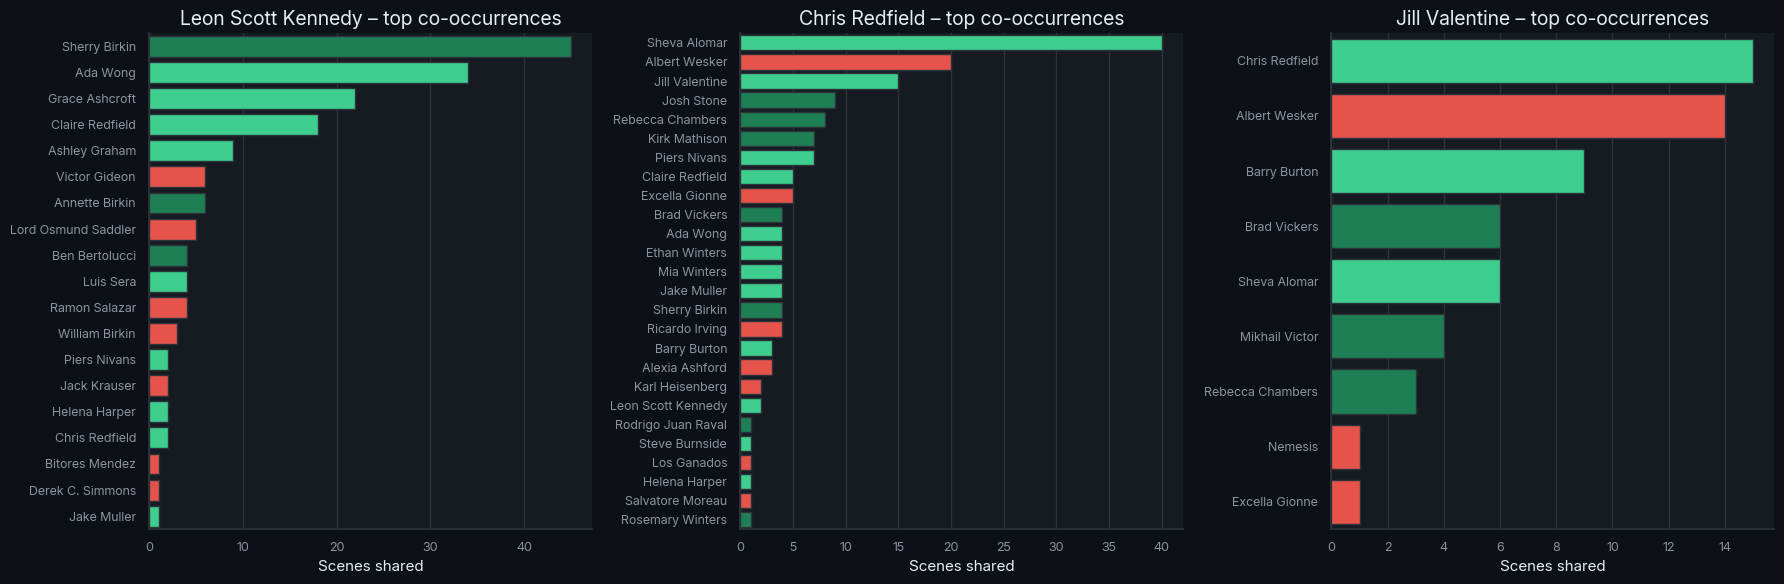

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False)

for char_id, ax in zip([1, 15, 16], axes):
    plot_ego_bar(char_id, top_n=35, ax=ax)

plt.tight_layout()
plt.savefig("co_occurrences.png")
plt.show()

Now, this three bar charts show the characters with the most shared scenes with Leon, Chris and Jill. Leon shares the most scenes with Sherry, followed by Ada, Grace and Claire, not many scenes with Ashley though. Remember we are considering cutscenes only, not the gameplay. As for Chris, he seems to shere too many scenes with Sheva, which could be realistic since they've been together throughout the entire Resident Evil 5. Jill appeared most of the scenes with Chris and the villain Albert Wesker, followed by her S.T.A.R.S. teammate Barry Burton.

In [9]:
# Remove Revelations because I don't have interactions between characters (yet)
game_ids = ["re_re", "re_re2"]
gameAppearance = gameAppearance[~gameAppearance["game_id"].isin(game_ids)]

In [10]:
MIN_WEIGHT = 0

scene_chars = (
    interactions
    .groupby(["game_id", "scene_id"])["character_id"]
    .apply(lambda ids: list(set(ids)))
    .reset_index(name="chars")
)

edge_counter = Counter()

for _, row in scene_chars.iterrows():
    chars = row["chars"]
    for c1, c2 in itertools.combinations(sorted(chars), 2):
        edge_counter[(int(c1), int(c2))] += 1

edges_df = (
    pd.DataFrame(
        [(s, t, w) for (s, t), w in edge_counter.items()],
        columns=["source", "target", "weight"]
    )
)

G = nx.Graph()

for _, row in edges_df.iterrows():
    if row["weight"] >= MIN_WEIGHT:       
        G.add_edge(
            int(row["source"]),
            int(row["target"]),
            weight=int(row["weight"])
        )

print(f"Diameter: {nx.diameter(G)}")
print(f"Density {nx.density(G)}")
print(f"Average shortest path: {nx.average_shortest_path_length(G)}")
print(f"Average clustering: {nx.average_clustering(G)}")
print(f"Transitivity: {nx.transitivity(G)}")

Diameter: 5
Density 0.10901960784313726
Average shortest path: 2.552156862745098
Average clustering: 0.7214828205849878
Transitivity: 0.41897940913160253


After plotting a basic graph we can see some of its metrics. The diameter of the graph is 5, which means that each character needs at most 5 steps to reach any other, with an average of 2.55 steps (a typical example of the small-world phenomenon). A density of 0.11 means that the graph is quite sparse, but still well-connected. The average clustering is pretty high at 0.72, this metric shows how many neighbours of a node tend to be connected. Transitivity has a more global perspective compared to the average clustering, 42% of connected triples are closed into triangles, still a high value for the triadic closure, but lower than suggested by the local clustering. The transitivity has less sensitivity to low degree nodes than the average clustering metric has.

In [11]:
# Centrality
deg_c  = nx.degree_centrality(G)
bet_c  = nx.betweenness_centrality(G, normalized=True)
clo_c  = nx.closeness_centrality(G)
eig_c  = nx.eigenvector_centrality(G, max_iter=200)
prk_c = nx.pagerank(G, alpha=0.85)

id_to_name = characters.set_index("id")["name"].to_dict()

def top_n_from_dict(d, n=10):
    return sorted(d.items(), key=lambda x: x[1], reverse=True)[:n]

top10_degree     = top_n_from_dict(deg_c, 10)
top10_betweenness = top_n_from_dict(bet_c, 10)
top10_closeness   = top_n_from_dict(clo_c, 10)
top10_eigenvector = top_n_from_dict(eig_c, 10)
top10_pageRank = top_n_from_dict(prk_c, 10)

print("Top 10 – Degree centrality")
for node, val in top10_degree:
    print(f"{id_to_name.get(node, node)}: {val:.4f}")

print("\nTop 10 – Betweenness centrality")
for node, val in top10_betweenness:
    print(f"{id_to_name.get(node, node)}: {val:.4f}")

print("\nTop 10 – Closeness centrality")
for node, val in top10_closeness:
    print(f"{id_to_name.get(node, node)}: {val:.4f}")

print("\nTop 10 – Eigenvector centrality")
for node, val in top10_eigenvector:
    print(f"{id_to_name.get(node, node)}: {val:.4f}")
    
print("\nTop 10 – Page Rank")
for node, val in top10_pageRank:
    print(f"{id_to_name.get(node, node)}: {val:.4f}")

Top 10 – Degree centrality
Chris Redfield: 0.5200
Leon Scott Kennedy: 0.3800
Ada Wong: 0.2800
Claire Redfield: 0.2200
Sherry Birkin: 0.2000
Albert Wesker: 0.1800
Jill Valentine: 0.1800
Rebecca Chambers: 0.1600
Sheva Alomar: 0.1600
Ethan Winters: 0.1600

Top 10 – Betweenness centrality
Chris Redfield: 0.6519
Leon Scott Kennedy: 0.2846
Rebecca Chambers: 0.1518
Ada Wong: 0.0890
Claire Redfield: 0.0673
Jill Valentine: 0.0654
Grace Ashcroft: 0.0531
Ethan Winters: 0.0526
Rosemary Winters: 0.0421
Karl Heisenberg: 0.0293

Top 10 – Closeness centrality
Chris Redfield: 0.6667
Leon Scott Kennedy: 0.5556
Ada Wong: 0.5155
Claire Redfield: 0.5000
Sherry Birkin: 0.4950
Jake Muller: 0.4762
Helena Harper: 0.4762
Piers Nivans: 0.4717
Albert Wesker: 0.4673
Jill Valentine: 0.4545

Top 10 – Eigenvector centrality
Chris Redfield: 0.4060
Leon Scott Kennedy: 0.3614
Ada Wong: 0.3243
Sherry Birkin: 0.2753
Claire Redfield: 0.2467
Jake Muller: 0.2182
Helena Harper: 0.2182
Piers Nivans: 0.2057
Albert Wesker: 0.158

Now, let's talk a bit about the difference **centrality** metrics. Centrality measures how important a node is in the network. **Degree** centrality simply counts how many connections each node has, the biggest nodes are the ones with the most connections (in case of weighted graphs, we can sum the strength of the edges). The values we got are normalised, Chris having a degree centrality of 0.52 means that he is connected with 52% of the nodes. **Betweenness** centrality is a little more tricky, it measures how often a node lies on shortest paths, characters with a high value of betweenness are the bridges of the graph that connects different part of the network. Chris has even more betweenness centrality, and compared with the degree centrality, he lies on more than 65% of shortest paths. In the graph we'll visualize later we will see that the network is divided in clusters, with Chris often being the bridge between them, explaining the high values in betweenness centrality. **Closeness** is the inverse of the sum of the distance between a node and all the others, Characters with high closeness are close to the other characters, there isn't a character that Chris cannot reach in two or fewer jumps, hence his high closeness. The next metric of centrality is the **Eigenvector**, it rewards nodes that are connected with high centrality nodes. Chris is, again, the one with the highest eigenvector centrality, making him the most influential node. Having lots of connection with peripheral nodes doesn't contribute much to eigenvector centrality. The formula for the eigenvector centrality uses a matrix of adjacency (0/1 for non weighted graphs, otherwise the strength of the edges) and the eigenvalues. Finally, **PageRank** was created for search engines and is similar to the Eigenvector centrality. Besides who a node is connected to, it also takes into account a damping factor to normalise the value (ensuring that every node has a possibility of being viewed). Leon, the highest in PageRank, he is a key character connected with the most influential ones (Chris, Ada, Claire, Jill,...). Chris and Leon are the ones that dominates throughout the metrics (always the top 2). 

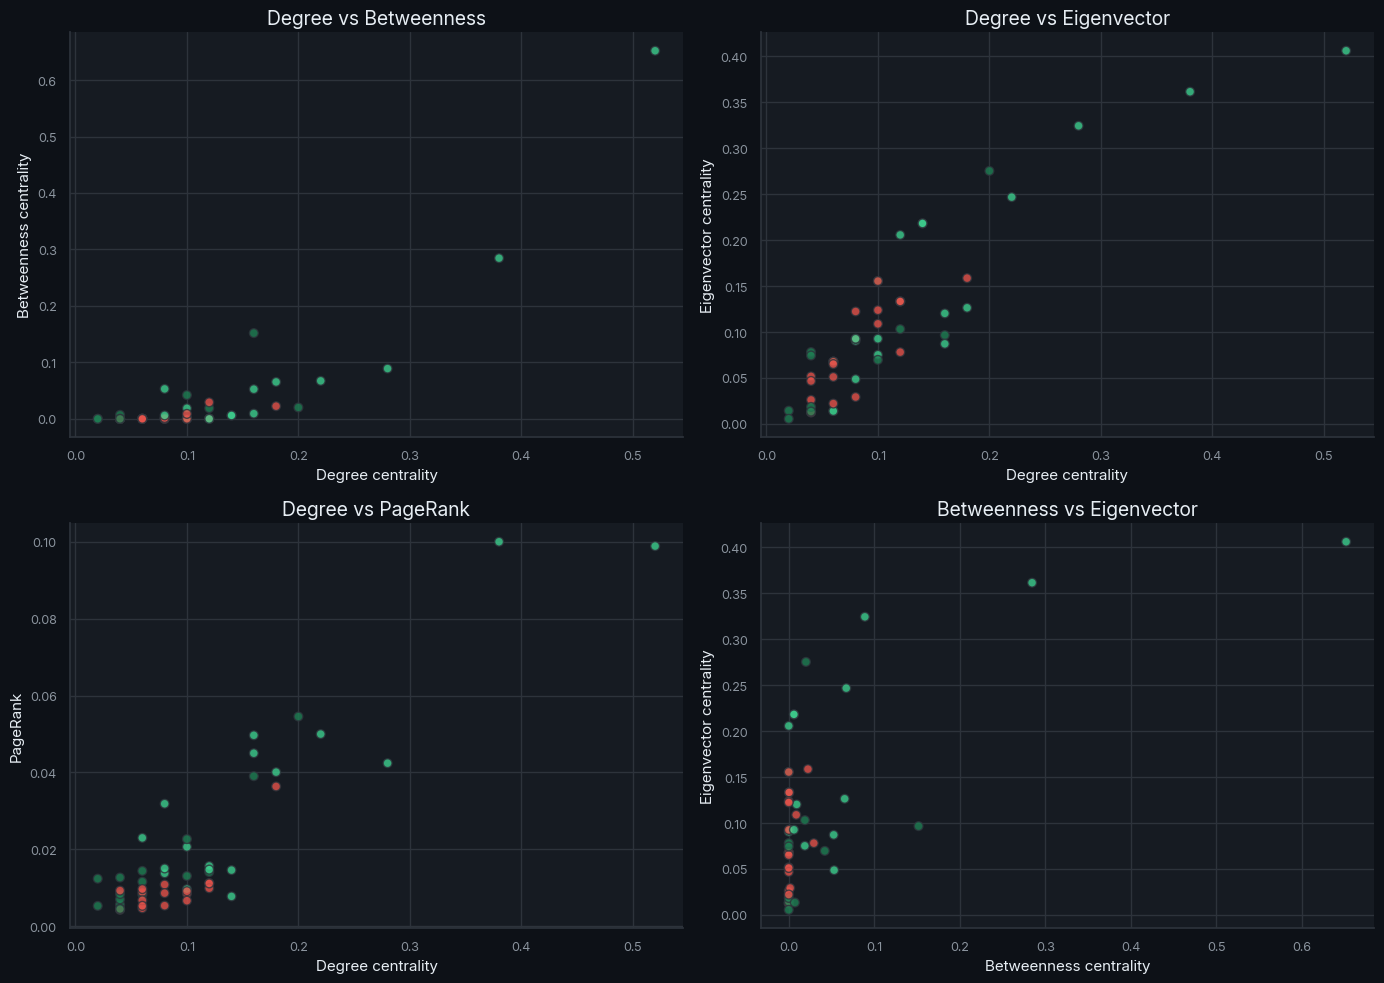

In [12]:
cent_df = (
    pd.DataFrame({
        "id": list(G.nodes()),
        "degree": [deg_c[n] for n in G.nodes()],
        "betweenness": [bet_c[n] for n in G.nodes()],
        "closeness": [clo_c[n] for n in G.nodes()],
        "eigenvector": [eig_c[n] for n in G.nodes()],
        "pagerank": [prk_c[n] for n in G.nodes()],
    })
    .merge(characters[["id", "name", "role"]], on="id", how="left")
)

cent_df["color"] = cent_df["role"].apply(role_to_color)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Degree vs Betweenness
axes[0, 0].scatter(
    cent_df["degree"], cent_df["betweenness"],
    c=cent_df["color"], edgecolor=border_subtle, alpha=0.8, s=40,
)
axes[0, 0].set_xlabel("Degree centrality")
axes[0, 0].set_ylabel("Betweenness centrality")
axes[0, 0].set_title("Degree vs Betweenness")

# Degree vs Eigenvector
axes[0, 1].scatter(
    cent_df["degree"], cent_df["eigenvector"],
    c=cent_df["color"], edgecolor=border_subtle, alpha=0.8, s=40,
)
axes[0, 1].set_xlabel("Degree centrality")
axes[0, 1].set_ylabel("Eigenvector centrality")
axes[0, 1].set_title("Degree vs Eigenvector")

# Degree vs PageRank
axes[1, 0].scatter(
    cent_df["degree"], cent_df["pagerank"],
    c=cent_df["color"], edgecolor=border_subtle, alpha=0.8, s=40,
)
axes[1, 0].set_xlabel("Degree centrality")
axes[1, 0].set_ylabel("PageRank")
axes[1, 0].set_title("Degree vs PageRank")

# Betweenness vs Eigenvector
axes[1, 1].scatter(
    cent_df["betweenness"], cent_df["eigenvector"],
    c=cent_df["color"], edgecolor=border_subtle, alpha=0.8, s=40,
)
axes[1, 1].set_xlabel("Betweenness centrality")
axes[1, 1].set_ylabel("Eigenvector centrality")
axes[1, 1].set_title("Betweenness vs Eigenvector")

plt.tight_layout()
plt.savefig("centrality_comparison.png")
plt.show()

These scatter plots compare different centrality measures for each character. Degree, Eigenvector, and PageRank show a strong positive relationship, meaning that characters with many connections tend to be linked to other influential ones. In contrast, Betweenness looks more skewed and characters like Chris and Leon act as major bridges, most of the other characters have very low betweenness centrality (<0.1). 

I want to specify that all the centrality values are normalized (scaled between 0 and 1) to ensure a correct comparison.

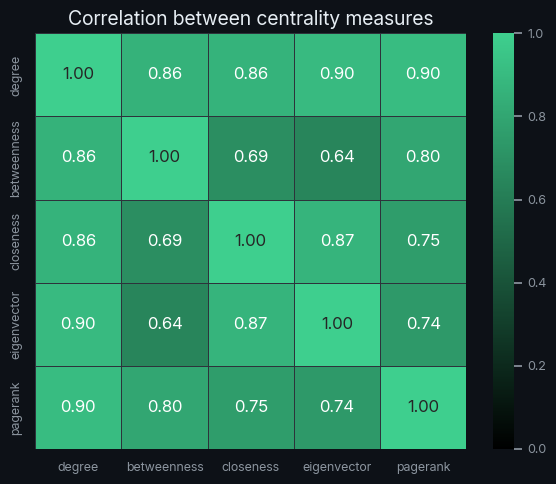

In [13]:
corr = cent_df[["degree", "betweenness", "closeness", "eigenvector", "pagerank"]].corr()

cm_corr = LinearSegmentedColormap.from_list(
    "re_corr",
    ["#000000", accent]   
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap=cm_corr,
    vmin=0,
    vmax=1,
    linewidths=.5,
    linecolor=border_subtle
)
plt.title("Correlation between centrality measures")
plt.tight_layout()
plt.savefig("centrality_correlation.png")
plt.show()

This is a correlation matrix between the different centrality measures and it confirms what we talked before: Degree, Closeness, Eigenvector, and PageRank are all strongly correlated, while betweenness is less correlated. The result is that not all central characters are strong bridges.

In [14]:
for col in ["degree", "betweenness", "closeness", "eigenvector"]:
    rank_col = col + "_rank"
    cent_df[rank_col] = cent_df[col].rank(ascending=False, method="min")

cent_df["total_rank"] = (
    cent_df["degree_rank"]
    + cent_df["betweenness_rank"]
    + cent_df["closeness_rank"]
    + cent_df["eigenvector_rank"]
)
cent_df["mean_rank"] = cent_df["total_rank"] / 4

top_mask = (
    (cent_df["degree_rank"] <= 10) |
    (cent_df["betweenness_rank"] <= 10) |
    (cent_df["closeness_rank"] <= 10) |
    (cent_df["eigenvector_rank"] <= 10)
)

rank_table = (
    cent_df.loc[
        top_mask,
        [
            "name",
            "role",
            "degree_rank",
            "betweenness_rank",
            "closeness_rank",
            "eigenvector_rank",
            "total_rank",
            "mean_rank",
        ],
    ]
    .sort_values("total_rank")
    .reset_index(drop=True)
)

rank_table

,name,role,degree_rank,betweenness_rank,closeness_rank,eigenvector_rank,total_rank,mean_rank
0,Chris Redfield,hero,1.0,1.0,1.0,1.0,4.0,1.00
1,Leon Scott Kennedy,hero,2.0,2.0,2.0,2.0,8.0,2.00
2,Ada Wong,hero,3.0,4.0,3.0,3.0,13.0,3.25
3,Claire Redfield,hero,4.0,5.0,4.0,5.0,18.0,4.50
4,Sherry Birkin,support,5.0,12.0,5.0,4.0,26.0,6.50
5,Albert Wesker,villain,6.0,11.0,9.0,9.0,35.0,8.75
6,Jill Valentine,hero,6.0,6.0,10.0,15.0,37.0,9.25
7,Jake Muller,hero,11.0,19.0,6.0,6.0,42.0,10.50
8,Helena Harper,hero,11.0,19.0,6.0,7.0,43.0,10.75
9,Rebecca Chambers,support,8.0,3.0,11.0,21.0,43.0,10.75


Number of characters per role:
role
villain    31
support    29
hero       23
Name: count, dtype: int64

Mixing matrix:
[[0.23741007 0.11870504 0.16906475]
 [0.11870504 0.04316547 0.03597122]
 [0.16906475 0.03597122 0.07194245]]


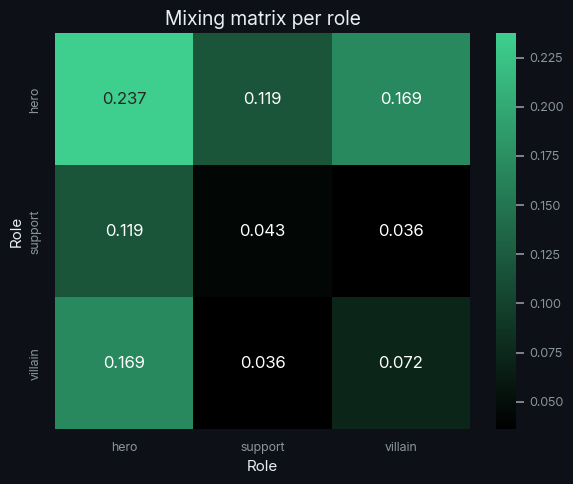

In [15]:
role_dict = characters.set_index("id")["role"].to_dict()

nx.set_node_attributes(G, role_dict, "role")

roles_unique = sorted(set(role_dict.values()))
role_to_idx = {r: i for i, r in enumerate(roles_unique)}

mix = nx.attribute_mixing_matrix(
    G,
    attribute="role",
    mapping=role_to_idx,
    normalized=True,
)


role_counts = characters["role"].value_counts()
print("Number of characters per role:")
print(role_counts)

print("\nMixing matrix:")
print(mix)

plt.figure(figsize=(6, 5))
sns.heatmap(
    mix,
    annot=True,
    fmt=".3f",
    xticklabels=roles_unique,
    yticklabels=roles_unique,
    cmap=cm_corr,
)
plt.xlabel("Role")
plt.ylabel("Role")
plt.title("Mixing matrix per role")
plt.tight_layout()
plt.savefig("mixing_matrix_role.png")
plt.show()

Here's a mixing matrix per role. Each cell gives us the probability that an edge connects two characters with the corresponding pair or roles (all cells sums to 1).
Even though hero is the least frequent role, it's actually the one that has the most probability to appear in both ends of a connection. Protagonists tend to have relationships with each others, while support roles interact through the protagonists rather than forming their own connections. 

In [16]:
cliques = list(nx.find_cliques(G)) 

print(f"Numer of cliques: {len(cliques)}")

cliques_k = [c for c in cliques if len(c) >= 3]

print(f"Numer of cliques with at least 3 characters: {len(cliques_k)}")

N = 10
cliques_k_sorted = sorted(cliques_k, key=len, reverse=True)[:N]

for i, clique in enumerate(cliques_k_sorted, start=1):
    names = [id_to_name.get(n, str(n)) for n in clique]
    print(f"Clique #{i} (size={len(clique)}): {', '.join(names)}")

Numer of cliques: 32
Numer of cliques with at least 3 characters: 28
Clique #1 (size=7): Chris Redfield, Leon Scott Kennedy, Ada Wong, Sherry Birkin, Jake Muller, Helena Harper, Piers Nivans
Clique #2 (size=6): Ashley Graham, Leon Scott Kennedy, Lord Osmund Saddler, Ramon Salazar, Ada Wong, Jack Krauser
Clique #3 (size=6): William Birkin, Leon Scott Kennedy, Claire Redfield, Sherry Birkin, Ada Wong, Annette Birkin
Clique #4 (size=5): Ashley Graham, Leon Scott Kennedy, Lord Osmund Saddler, Ramon Salazar, Luis Sera
Clique #5 (size=5): Chris Redfield, Leon Scott Kennedy, Ada Wong, Sherry Birkin, Claire Redfield
Clique #6 (size=5): Chris Redfield, Albert Wesker, Jill Valentine, Brad Vickers, Barry Burton
Clique #7 (size=5): Chris Redfield, Albert Wesker, Jill Valentine, Brad Vickers, Rebecca Chambers
Clique #8 (size=5): Chris Redfield, Albert Wesker, Jill Valentine, Sheva Alomar, Excella Gionne
Clique #9 (size=5): Derek C. Simmons, Leon Scott Kennedy, Sherry Birkin, Jake Muller, Helena Har

A clique is a fully connected group of characters. In our network we have 28 cliques with at least 3 characters, the largest one has size 7 and is composed of Chris, Leon, Ada, Sherry, Jake Muller, Helena Harper and Piers Nivans. The characters in this group are all connected with one another and appeared together in Resident Evil 6. Another interesting clique is formed by Chris Redfield, Ethan, Mia, and Rosemary Winters, which represents the Winters family cycle that interacted with Chris Redfield in Resident Evil Village.

In [17]:
id_to_role = characters.set_index("id")["role"].to_dict()

def triad_role_type(u, v, w):
    roles = sorted([id_to_role.get(u), id_to_role.get(v), id_to_role.get(w)])
    return tuple(roles) 

motif_counts = Counter()

for u, v, w in combinations(G.nodes(), 3):
    if G.has_edge(u, v) and G.has_edge(u, w) and G.has_edge(v, w):
        motif_counts[triad_role_type(u, v, w)] += 1

print("Motif of triads per role (only cliques with at least 3 characters):")
for roles, cnt in motif_counts.most_common():
    print(f"{roles}: {cnt}")

Motif of triads per role (only cliques with at least 3 characters):
('hero', 'hero', 'villain'): 40
('hero', 'hero', 'support'): 33
('hero', 'hero', 'hero'): 29
('hero', 'villain', 'villain'): 22
('hero', 'support', 'villain'): 21
('hero', 'support', 'support'): 6
('support', 'support', 'villain'): 2
('villain', 'villain', 'villain'): 2
('support', 'support', 'support'): 1


By studying the **motif of triads**, we select the cliques with exactly 3 characters and analyze the combinations of roles in such groups. The most common triads contain two heroes and one villain. Patterns made of two heroes and a support character, as well as triads with three heroes, are quite common too. On the other hand, triads with at least two support characters are very rare in our network.

Grafo: 49 nodi, 137 archi


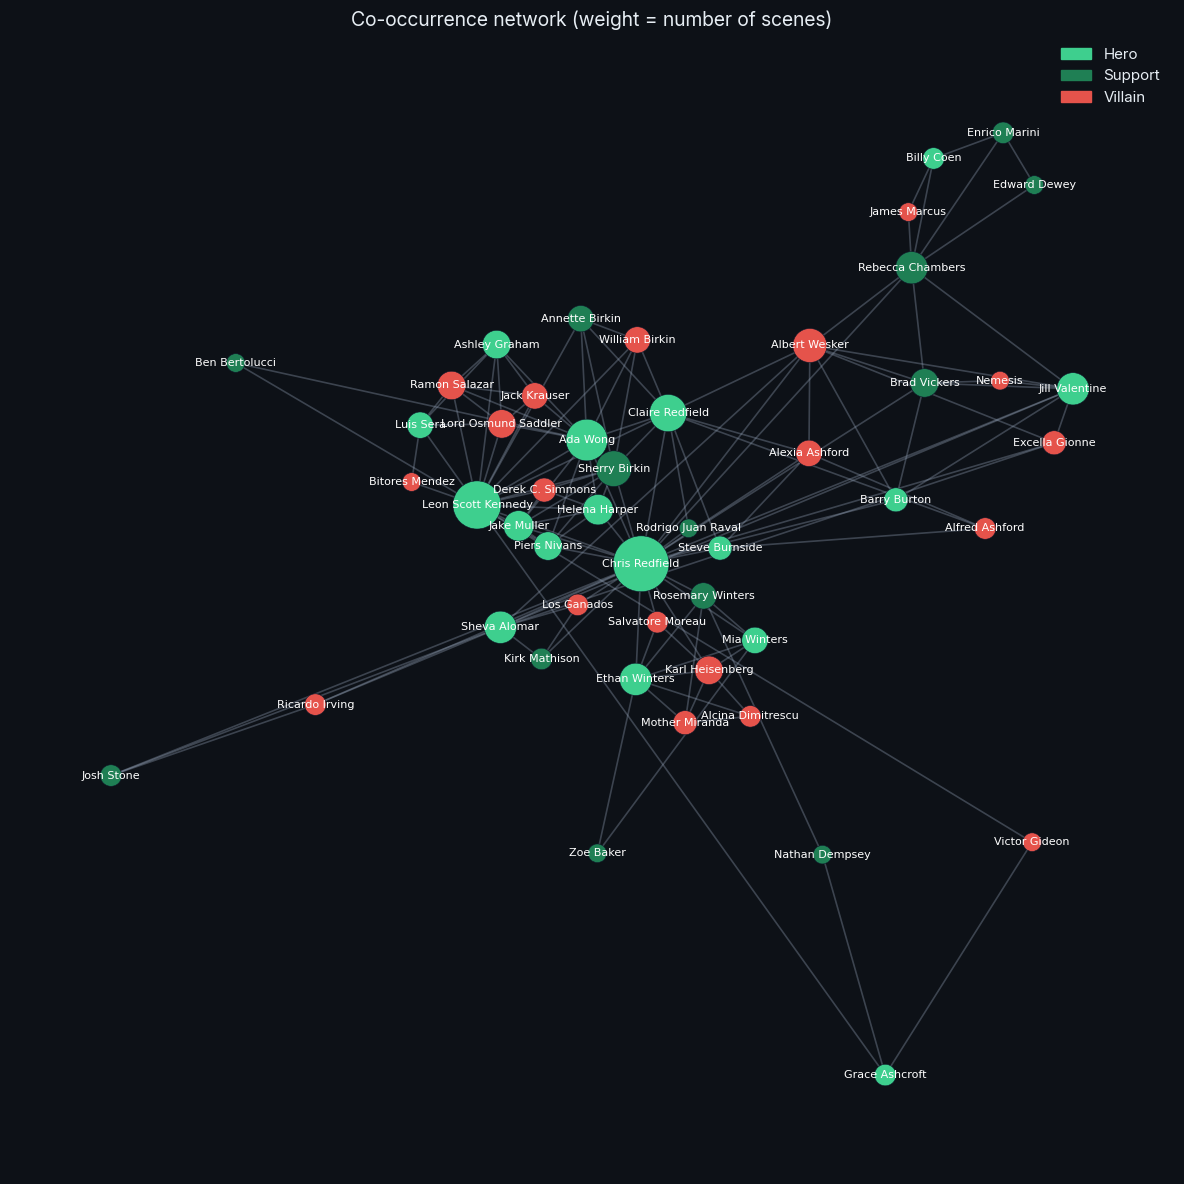

In [18]:
isolated_nodes = list(nx.isolates(G))
G.remove_nodes_from(isolated_nodes)

degree_dict = dict(G.degree())
nodes_deg1 = [n for n, d in degree_dict.items() if d == 1]
G.remove_nodes_from(nodes_deg1)

print(f"Grafo: {G.number_of_nodes()} nodi, {G.number_of_edges()} archi")

# Recalculate
degree_dict = dict(G.degree())

plt.figure(figsize=(12, 12))
pos = nx.kamada_kawai_layout(G)

nx.draw_networkx_edges(
    G, pos,
    alpha=0.35,
    width=1.2,
    edge_color="#94a3b8"
)

node_sizes = [60 + 60 * degree_dict[n] for n in G.nodes()]

color_map = {
    "hero":    accent,
    "support": accent_dark,
    "villain": villain
}
node_colors = [
    color_map.get(id_to_role.get(n), accent_dark)
    for n in G.nodes()
]

nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors="#0f172a",
    linewidths=0.4
)


top_nodes = sorted(degree_dict, key=degree_dict.get, reverse=True)[:90]
top_nodes = [n for n in top_nodes if n in G]  
labels = {n: id_to_name.get(n, str(n)) for n in top_nodes}

nx.draw_networkx_labels(
    G, pos,
    labels=labels,
    font_size=8,
    font_color="white"
)


for n in G.nodes():
    G.nodes[n]["label"] = id_to_name.get(n, str(n))      
    G.nodes[n]["role"] = id_to_role.get(n, "unknown")
    G.nodes[n]["degree"] = degree_dict.get(n, 0)

# Export for Gephi
nx.write_gexf(G, "co_occurrence.gexf")

plt.axis("off")
plt.title("Co-occurrence network (weight = number of scenes)")

hero_patch    = mpatches.Patch(color=accent,      label="Hero")
support_patch = mpatches.Patch(color=accent_dark, label="Support")
villain_patch = mpatches.Patch(color=villain,     label="Villain")

plt.legend(
    handles=[hero_patch, support_patch, villain_patch],
    loc="upper right",
    frameon=False
)

plt.tight_layout()
plt.savefig("co-occurrence_network.png")
plt.show()

In the graph above we finally draw the network. For clear visualization we removed isolated characters and scaled the size of the nodes proportionally to their degree. Nodes are colored by their narrative role (hero, villain and support). The graph pretty much sums what we talked before, Chris is the most central character and can reach any other node in at most two steps. The graph is quite sparse, but an average shortest path of 2.5 enables the nodes reach the others in fewer steps. The triadic closure is quite common, meaning that if two characters share a common neighbor, they are often connected as well.

## Community Detection

In [19]:
partition = community_louvain.best_partition(G, weight="weight")

cent_df["community"] = cent_df["id"].map(partition)

# Basic stats per community
comm_stats = (
    cent_df
    .groupby("community")
    .agg(
        n_nodes=("id", "size"),
        avg_degree=("degree", "mean"),
        avg_betweenness=("betweenness", "mean"),
        avg_closeness=("closeness", "mean"),
        avg_eigenvector=("eigenvector", "mean"),
    )
    .reset_index()
)

# Role composition
role_counts = (
    cent_df
    .groupby(["community", "role"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

comm_stats = comm_stats.merge(role_counts, on="community", how="left")
comm_stats.sort_values("n_nodes", ascending=False, inplace=True)

comm_stats.head(10)

,community,n_nodes,avg_degree,avg_betweenness,avg_closeness,avg_eigenvector,hero,support,villain
3,3.0,22,0.122727,0.024306,0.415399,0.151965,10,4,8
0,0.0,13,0.130769,0.059736,0.437635,0.115660,4,3,6
2,2.0,9,0.084444,0.016841,0.383261,0.050982,2,3,4
1,1.0,5,0.072000,0.030531,0.342459,0.030008,1,3,1


In [20]:
cent_df_no_nan = cent_df[cent_df["community"].notna()]

for comm_id in sorted(cent_df_no_nan["community"].unique()):
    members = (
        cent_df_no_nan.loc[cent_df_no_nan["community"] == comm_id, ["name", "role"]]
        .sort_values("name")
    )
    names = members["name"].tolist()
    print(f"Community {comm_id} ({len(names)} characters):")
    print(", ".join(names))
    print()

Community 0.0 (13 characters):
Albert Wesker, Alexia Ashford, Barry Burton, Brad Vickers, Chris Redfield, Excella Gionne, Jill Valentine, Josh Stone, Kirk Mathison, Los Ganados, Nemesis, Ricardo Irving, Sheva Alomar

Community 1.0 (5 characters):
Billy Coen, Edward Dewey, Enrico Marini, James Marcus, Rebecca Chambers

Community 2.0 (9 characters):
Alcina Dimitrescu, Ethan Winters, Karl Heisenberg, Mia Winters, Mother Miranda, Nathan Dempsey, Rosemary Winters, Salvatore Moreau, Zoe Baker

Community 3.0 (22 characters):
Ada Wong, Alfred Ashford, Annette Birkin, Ashley Graham, Ben Bertolucci, Bitores Mendez, Claire Redfield, Derek C. Simmons, Grace Ashcroft, Helena Harper, Jack Krauser, Jake Muller, Leon Scott Kennedy, Lord Osmund Saddler, Luis Sera, Piers Nivans, Ramon Salazar, Rodrigo Juan Raval, Sherry Birkin, Steve Burnside, Victor Gideon, William Birkin



Now we have detected the communities in our network and found four distinct groups: Leon and the Raccoon city arc, Chris and the BSAA arc, the Village arc, and the RE0 and Bravo Team arc. The Raccoon city arc is by far the largest with 22 characters, and also the highest overall values of centrality. Meanwhile the Bravo team community only has 5 members, but the highest value in betweenness centrality,being only connected to the network through Rebecca Chambers. The communities show that The Village and the Bravo team arcs behave more like a self-contained narrative stories, compared to the others.

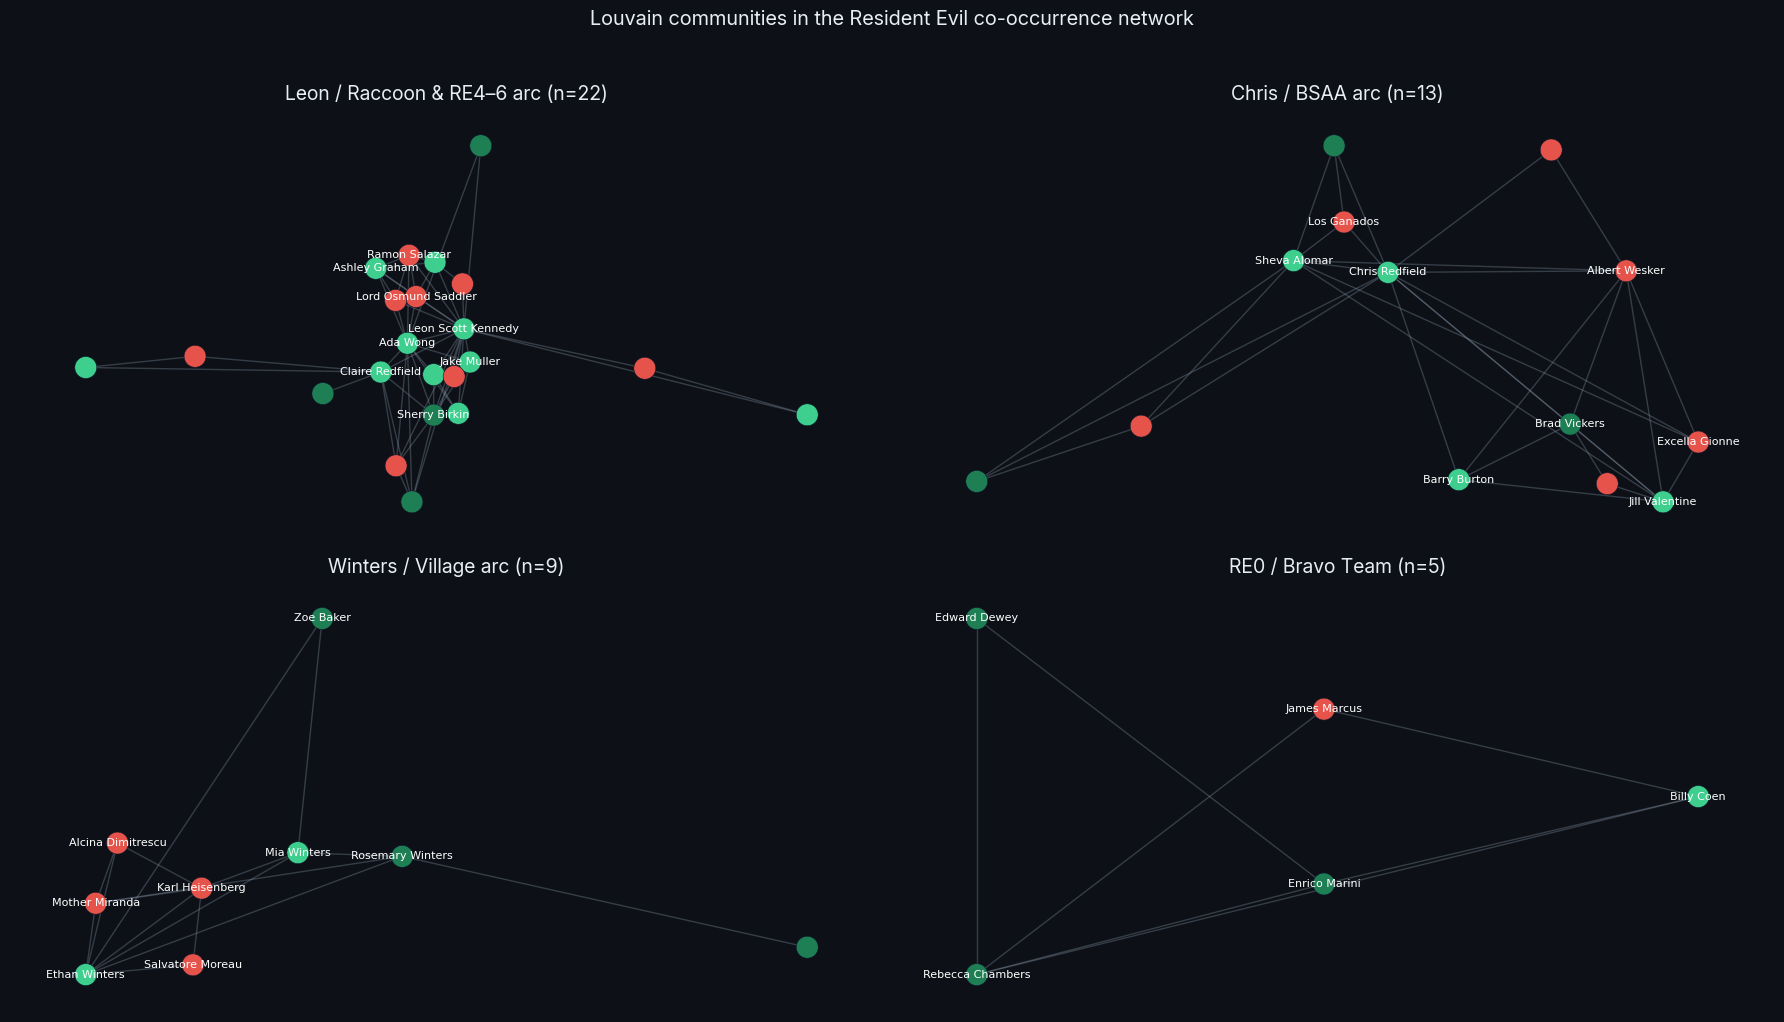

In [21]:
# Map community id -> descriptive label
community_labels = {
    3.0: "Leon / Raccoon & RE4–6 arc",
    0.0: "Chris / BSAA arc",
    2.0: "Winters / Village arc",
    1.0: "RE0 / Bravo Team",
}

top_comms = (
    comm_stats
    .sort_values("n_nodes", ascending=False)
    .head(4)["community"]
    .tolist()
)

subgraphs = {c: G.subgraph(cent_df[cent_df["community"] == c]["id"]) for c in top_comms}
pos = {c: nx.kamada_kawai_layout(subgraphs[c]) for c in top_comms}

n_cols, n_rows = 2, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(9*n_cols, 5*n_rows))
axes = axes.flatten()

for ax, comm_id in zip(axes, top_comms):
    H = subgraphs[comm_id]
    if len(H) == 0:
        ax.axis("off")
        continue

    roles = [id_to_role.get(n, "support") for n in H.nodes()]
    colors = [color_map.get(r, accent_dark) for r in roles]

    nx.draw_networkx_edges(
        H, pos[comm_id], ax=ax,
        alpha=0.3, width=1.0, edge_color="#94a3b8"
    )

    nx.draw_networkx_nodes(
        H, pos[comm_id], ax=ax,
        node_color=colors,
        node_size=250,
        edgecolors="#0f172a",
        linewidths=0.4
    )

    degs = dict(H.degree())
    top_nodes = sorted(degs, key=degs.get, reverse=True)[:8]
    labels = {n: id_to_name.get(n, str(n)) for n in top_nodes}

    nx.draw_networkx_labels(
        H, pos[comm_id], labels=labels,
        font_size=8, font_color="white", ax=ax
    )

    label = community_labels.get(comm_id, f"Community {comm_id}")
    ax.set_title(f"{label} (n={H.number_of_nodes()})")
    ax.axis("off")

plt.suptitle("Louvain communities in the Resident Evil co-occurrence network", y=1.02)
plt.tight_layout()
plt.savefig("communities_graph.png")
plt.show()

In the graphs above we can see these four communities. Leon and Chris are the central characters of their groups, that connect all the others. The bravo team group represent the first episodes of the franchise, while the Village group the more recent ones. 